In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
house=pd.read_csv(r'/Users/aayushraj/Downloads/bengaluru_house_prices.csv.xls')
house

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [10]:
house.shape

(13320, 9)

In [11]:
house.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [23]:
house= house.drop(['area_type','availability','society'], axis=1)


In [25]:
house = house.dropna()

In [26]:
house['bhk'] = house['size'].apply(lambda x: int(x.split(' ')[0]))
house = house.drop('size', axis=1)

In [29]:
location_dummies = pd.get_dummies(house['location'])
house = pd.concat([house, location_dummies], axis=1)
house = house.drop('location', axis=1)

In [30]:
X = house.drop('price', axis=1)

y = house['price']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

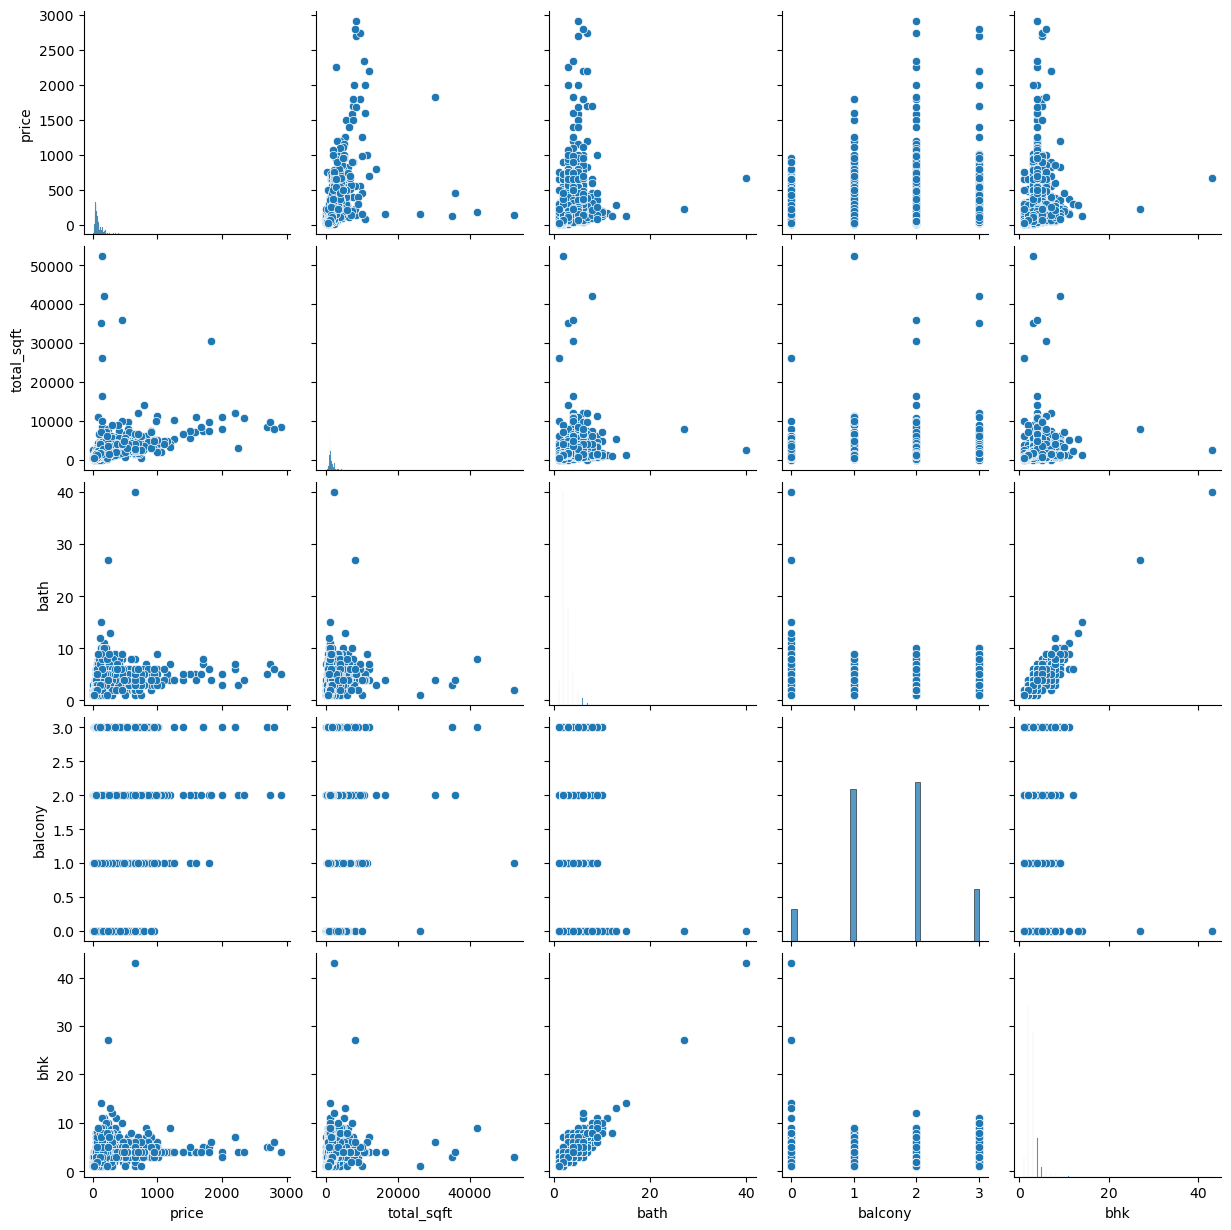

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_data = house[['price','total_sqft','bath','balcony','bhk']]

sns.pairplot(pairplot_data)

plt.show()

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [33]:
predictions = model.predict(X_test)

print(predictions[:10])

[126.22098497  54.9723411  198.52527295 146.52519907 216.42488421
 137.5978864   57.07545967  66.46131536 124.28843931  32.19739695]


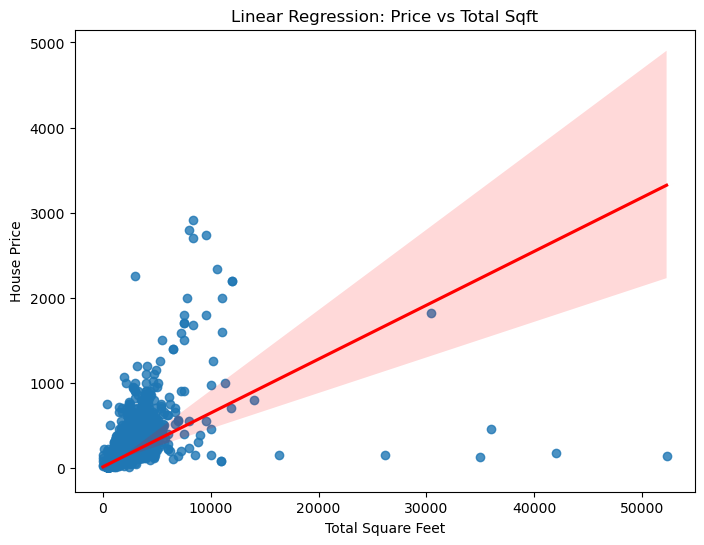

In [41]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='total_sqft',
    y='price',
    data=house,
    line_kws={"color": "red"}
)

plt.title("Linear Regression: Price vs Total Sqft")
plt.xlabel("Total Square Feet")
plt.ylabel("House Price")

plt.show()

In [36]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 38.465245403594274
MSE: 10855.26395085738
RMSE: 104.18859798873089
R2 Score: 0.49469474890440923
